# Setup

In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
from eyewire2_functional_analysis import data_loader

data_folder = "../../../data/preprocessed-data"
morph_folder = "../../../data/morphological-data"

In [3]:
df_rois, df_fields, df_outline= data_loader.load_all_dfs(data_folder)

In [4]:
df = data_loader.load_df_rois_morph(
    morph_folder=morph_folder,
    morph_spreadsheet_filename='Eyewire II Proofread Cells Master List - All Cells 2026-03-17.csv',
    nuc_col_master='Final NucID',
    seg_col_master='Final SegID',
    df_rois=df_rois,
)

## Stimuli

In [5]:
# You have to run mc_to_numpy.py first, before loading the mc array

mc15 = np.load("../../../data/stimuli/mouse_cam_movies/mc_arrays/MC15.npy")
assert mc15.shape[0] == 123 * 5 * 30
mc15.shape

(18450, 56, 56, 3)

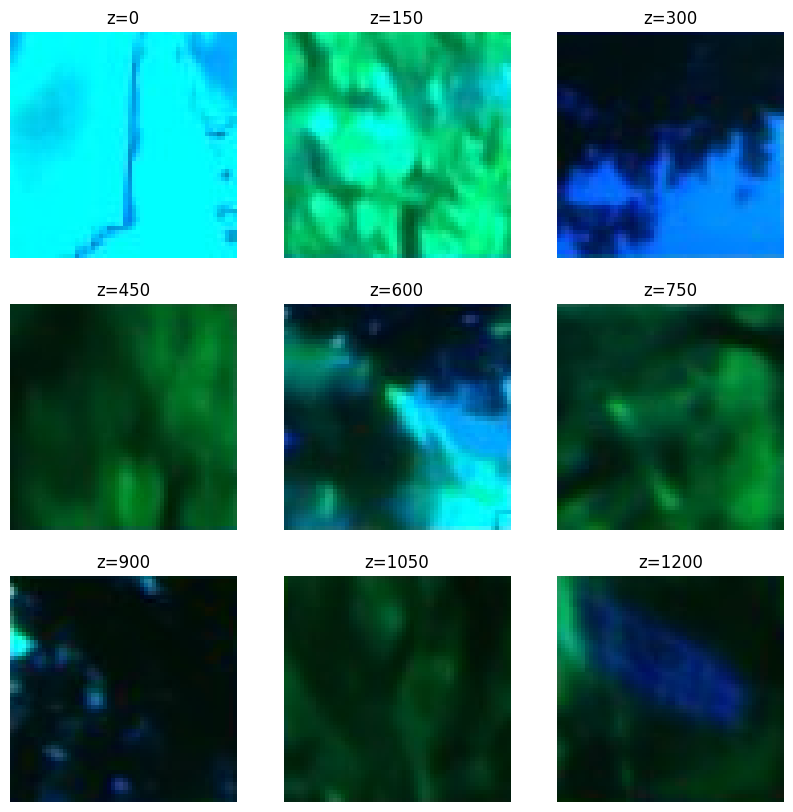

In [6]:
fig, axs = plt.subplots(3, 3, figsize=(10, 10))

for i, ax in enumerate(axs.flat):
    frame = i * 150
    ax.set(xticks=[], yticks=[], title=f"z={frame}")
    ax.imshow(mc15[frame, :, :])
    ax.axis('off')

# Plot

In [7]:
from eyewire2_functional_analysis import plot

In [8]:
row = df.iloc[0]

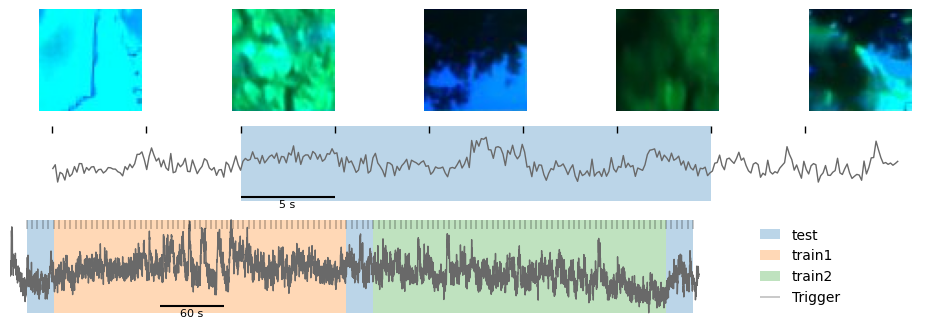

In [9]:
fig, axs = plt.subplot_mosaic(
    """
    EFGHI
    CCCCC
    CCCCC
    CCCCC
    DDDDD
    """,
    figsize=(12, 4),
    width_ratios=(0.3, 0.3, 0.3, 0.3, 0.3),
    height_ratios=(1, 0.2, 0.2, 0.2, 1),
)

ax = axs['D']
mc_trace = row.mc_trace
mc_time = np.arange(mc_trace.size) * row.mc_trace_dt + row.mc_trace_t0
mc_tt = row.mc_triggertimes
mc_tt = np.append(mc_tt, mc_tt[-1] + np.median(np.diff(mc_tt)))
mc_ylim = (mc_trace.min(), mc_trace.max())

ax.axis('off')
for test_i in [0, 59, 118]:
    ax.fill_between(x=[mc_tt[test_i], mc_tt[test_i + 5]], y1=mc_ylim[0], y2=mc_ylim[1], color='C0', alpha=0.3, lw=0,
                    label='test' if test_i == 0 else '_')

ax.fill_between(x=[mc_tt[5], mc_tt[5 + 54]], y1=mc_ylim[0], y2=mc_ylim[1], color='C1', alpha=0.3, lw=0, label='train1')
ax.fill_between(x=[mc_tt[59 + 5], mc_tt[59 + 54 + 5]], y1=mc_ylim[0], y2=mc_ylim[1], color='C2', alpha=0.3, lw=0,
                label='train2')

ax.plot(mc_time, mc_trace, c='dimgray', lw=1)
ax.vlines(mc_tt, ymin=mc_ylim[1] - np.diff(mc_ylim) * 0.1, ymax=mc_ylim[1], colors='k', linestyles='-', lw=0.3,
          label='Trigger')

ax.legend(bbox_to_anchor=(0.8, 0.5), loc='center left', borderaxespad=0., frameon=False, handlelength=1.5, )
plot.plot_scale_bar(ax=ax, x0=np.mean(mc_tt[:len(mc_tt) // 2]), y0=mc_ylim[0] + 3, size=60, text=True, unit='s',
                    tdist=1, fontsize=8)
ax.set_xlim(mc_time[0], mc_time[-1] + (mc_time[-1] - mc_time[0]) * 0.35)

ax = axs['C']
tlim_test2 = (mc_tt[59] - mc_tt[59 + 5])
ilim = (mc_time >= mc_tt[59] - 10) & (mc_time <= mc_tt[59 + 5] + 10)
ax.axis('off')
ax.plot(mc_time[ilim], mc_trace[ilim], c='dimgray', lw=1)
for test_i in [59]:
    ax.fill_between(x=[mc_tt[test_i], mc_tt[test_i + 5]], y1=mc_ylim[0], y2=mc_ylim[1], color='C0', alpha=0.3, lw=0,
                    label='test' if test_i == 0 else '_')

ax.vlines(mc_tt[59 - 2:59 + 5 + 2], ymin=mc_ylim[1] - np.diff(mc_ylim) * 0.1, ymax=mc_ylim[1], colors='k',
          linestyles='-', lw=1)
plot.plot_scale_bar(ax=ax, x0=mc_tt[59] + 2.5, y0=mc_ylim[0] + 2, size=5, text=True, unit='s', tdist=1, fontsize=8)

for i in range(5):
    seq = 59 + i
    frame = seq * 30 * 5
    ax = axs[['E', 'F', 'G', 'H', 'I'][i]]
    ax.set(xticks=[], yticks=[])
    ax.imshow(mc15[frame, :, :])
    ax.axis('off')